In [ ]:
import pandas as pd

df = pd.read_csv("Trees.csv") 

# Key columns
cols = ["DBH", "CROWN_AREA", "CROWN_HEIGHT"]

# Create a summary of missing values for the key columns
missing_summary = pd.DataFrame({
    "Missing Count": df[cols].isna().sum(),
    "Total Count": len(df),
})

missing_summary["Missing %"] = (missing_summary["Missing Count"] / len(df)) * 100

missing_summary

,Missing Count,Total Count,Missing %
DBH,0,55676,0.000000
CROWN_AREA,12684,55676,22.781809
CROWN_HEIGHT,29,55676,0.052087


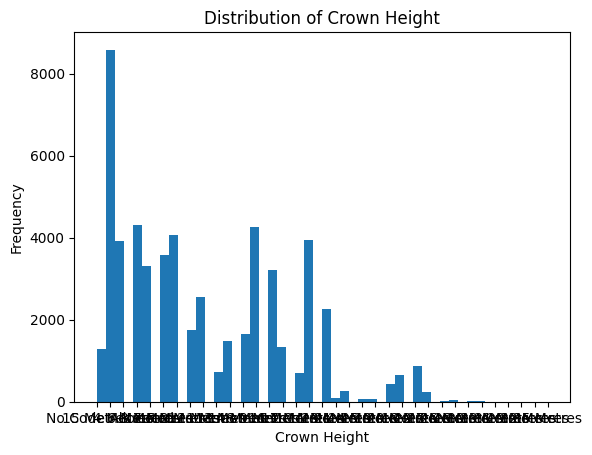

count                 55647
unique                   35
top       No Code Allocated
freq                   8583
Name: CROWN_HEIGHT, dtype: object

In [ ]:
import matplotlib.pyplot as plt

#plot the distribution of crown height values
plt.hist(df["CROWN_HEIGHT"].dropna(), bins=50)
plt.xlabel("Crown Height")
plt.ylabel("Frequency")
plt.title("Distribution of Crown Height")
plt.show()
df["CROWN_HEIGHT"].describe()

In [ ]:
# Check data types
print(df[["DBH", "CROWN_HEIGHT", "CROWN_AREA"]].dtypes)

# Check first 20 values to see what the data actually looks like
print(df["DBH"].head(20))
print(df["CROWN_HEIGHT"].head(20))
print(df["CROWN_AREA"].head(20))

DBH             object
CROWN_HEIGHT    object
CROWN_AREA      object
dtype: object
0     No Code Allocated
1     No Code Allocated
2         7 Centimetres
3         6 Centimetres
4     No Code Allocated
5        10 Centimetres
6         8 Centimetres
7        10 Centimetres
8        11 Centimetres
9        12 Centimetres
10       21 Centimetres
11       18 Centimetres
12    No Code Allocated
13       20 Centimetres
14       10 Centimetres
15        9 Centimetres
16       12 Centimetres
17       15 Centimetres
18       10 Centimetres
19       10 Centimetres
Name: DBH, dtype: object
0             15 Metres
1     No Code Allocated
2              4 Metres
3              4 Metres
4     No Code Allocated
5              6 Metres
6              4 Metres
7              6 Metres
8              3 Metres
9              7 Metres
10             5 Metres
11             7 Metres
12    No Code Allocated
13             4 Metres
14             4 Metres
15             4 Metres
16             3 Metres
17  

In [6]:
#now we know that there's categorical data, clean both the crown height and dbh columns 
# so that they only contain numerical values.

df["DBH_clean"] = (
    df["DBH"]
    .str.replace(" Centimetres", "", regex=False)
    .replace("No Code Allocated", pd.NA)
)

df["DBH_clean"] = pd.to_numeric(df["DBH_clean"], errors="coerce")

df["CROWN_HEIGHT_clean"] = (
    df["CROWN_HEIGHT"]
    .str.replace(" Metres", "", regex=False)
    .replace("No Code Allocated", pd.NA)
)

df["CROWN_HEIGHT_clean"] = pd.to_numeric(df["CROWN_HEIGHT_clean"], errors="coerce")

In [ ]:
#check the data types are floats and first few values
print(df[["DBH_clean", "CROWN_HEIGHT_clean"]].dtypes)
print(df[["DBH_clean", "CROWN_HEIGHT_clean"]].head())

#check the percentage of missing values in the cleaned columns because
#'no code allocated' was replaced with NA and should be counted as missing
df[["DBH_clean", "CROWN_HEIGHT_clean"]].isna().mean() * 100

DBH_clean             float64
CROWN_HEIGHT_clean    float64
dtype: object
   DBH_clean  CROWN_HEIGHT_clean
0        NaN                15.0
1        NaN                 NaN
2        7.0                 4.0
3        6.0                 4.0
4        NaN                 NaN


DBH_clean             10.253969
CROWN_HEIGHT_clean    15.468065
dtype: float64

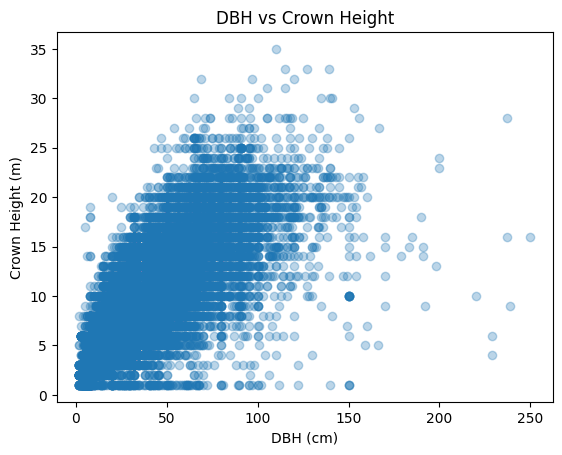

In [9]:
plot_df = df[["DBH_clean", "CROWN_HEIGHT_clean"]].dropna()

plt.scatter(plot_df["DBH_clean"], plot_df["CROWN_HEIGHT_clean"], alpha=0.3)
plt.xlabel("DBH (cm)")
plt.ylabel("Crown Height (m)")
plt.title("DBH vs Crown Height")
plt.show()

In [10]:
from sklearn.linear_model import LinearRegression
import numpy as np

#Model training
model_df = df[["DBH_clean", "CROWN_HEIGHT_clean"]].dropna()

X = model_df[["DBH_clean"]]
y = model_df["CROWN_HEIGHT_clean"]

#Linear regression model
lin_model = LinearRegression().fit(X, y)
y_pred_lin = lin_model.predict(X)

#Log model
X_log = np.log1p(model_df[["DBH_clean"]])

log_model = LinearRegression().fit(X_log, y)
y_pred_log = log_model.predict(X_log)

#Power law model
X_power = np.log(model_df["DBH_clean"])
y_power = np.log(model_df["CROWN_HEIGHT_clean"])

power_model = LinearRegression().fit(X_power.values.reshape(-1,1), y_power)

y_pred_power = np.exp(power_model.predict(X_power.values.reshape(-1,1)))



Linear RMSE: 2.9005645307366774
Log RMSE: 2.937915322242821
Power RMSE: 2.8366746743835396


/Users/oliviabrannan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/oliviabrannan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


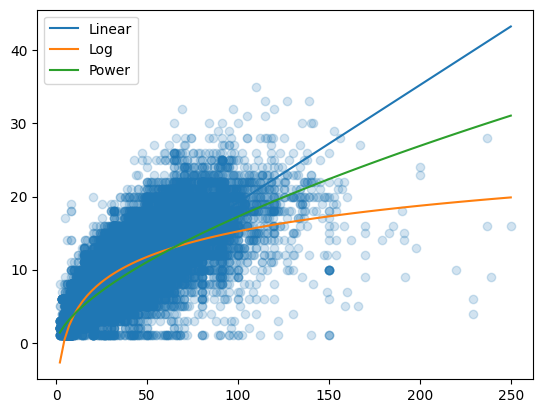

In [11]:
from sklearn.metrics import mean_squared_error

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

print("Linear RMSE:", rmse(y, y_pred_lin))
print("Log RMSE:", rmse(y, y_pred_log))
print("Power RMSE:", rmse(y, y_pred_power))

plt.scatter(X, y, alpha=0.2)

x_range = np.linspace(X.min(), X.max(), 100)

plt.plot(x_range, lin_model.predict(x_range.reshape(-1,1)), label="Linear")
plt.plot(x_range, log_model.predict(np.log1p(x_range).reshape(-1,1)), label="Log")
plt.plot(x_range, np.exp(power_model.predict(np.log(x_range).reshape(-1,1))), label="Power")

plt.legend()
plt.show()